In [25]:
# Imports
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import glob

In [26]:
# Import robot timestamp results
# Get all CSV files from the directory
moderate_load_files = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/robot-states-#1/*.csv")
high_load_files = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/robot-states-#1/*.csv")
# Read and combine all CSV files
dfs = [pd.read_csv(file, header=0, sep=',', dtype=np.longlong) for file in moderate_load_files]
moderate_load_df = pd.concat(dfs, ignore_index=True)
dfs = [pd.read_csv(file, header=0, sep=',', dtype=np.longlong) for file in high_load_files]
high_load_df = pd.concat(dfs, ignore_index=True)

# Import completed order timestamp files
moderate_load_completed_file = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/kitchen-states-#1/*completed*.csv")
high_load_completed_file = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/kitchen-states-#1/*completed*.csv")
# Import received order timestamp files
moderate_load_received_file = glob.glob("../timestamp_results/thesis-eval-experiments/moderate-load/kitchen-states-#1/*received*.csv")
high_load_received_file = glob.glob("../timestamp_results/thesis-eval-experiments/high-load/kitchen-states-#1/*received*.csv")
# Read and combine all CSV files
moderate_load_completed_df = pd.read_csv(filepath_or_buffer=moderate_load_completed_file[0], header=0, sep=',', dtype=np.longlong)
high_load_completed_df = pd.read_csv(filepath_or_buffer=high_load_completed_file[0], header=0, sep=',', dtype=np.longlong)
moderate_load_received_df = pd.read_csv(filepath_or_buffer=moderate_load_received_file[0], header=0, sep=',', dtype=np.longlong)
high_load_received_df = pd.read_csv(filepath_or_buffer=high_load_received_file[0], header=0, sep=',', dtype=np.longlong)

In [27]:
# Get t0 reference timestamp from received order timestamps for moderate load
t0_reference_moderate = moderate_load_received_df.loc[moderate_load_received_df['ReceivedOrdersCount'] == 1, 'Timestamp'].iloc[0]
# Set t0 reference moderate load
moderate_load_df['Timestamp'] = moderate_load_df['Timestamp'] - t0_reference_moderate
moderate_load_df['Timestamp'] = moderate_load_df['Timestamp'].clip(lower=0)
moderate_load_completed_df['Timestamp'] = moderate_load_completed_df['Timestamp'] - t0_reference_moderate
moderate_load_completed_df['Timestamp'] = moderate_load_completed_df['Timestamp'].clip(lower=0)
moderate_load_received_df['Timestamp'] = moderate_load_received_df['Timestamp'] - t0_reference_moderate
moderate_load_received_df['Timestamp'] = moderate_load_received_df['Timestamp'].clip(lower=0)
# Get t0 reference timestamp from received order timestamps for high load
t0_reference_high = high_load_received_df.loc[high_load_received_df['ReceivedOrdersCount'] == 1, 'Timestamp'].iloc[0]
# Set t0 reference high load
high_load_df['Timestamp'] = high_load_df['Timestamp'] - t0_reference_high
high_load_df['Timestamp'] = high_load_df['Timestamp'].clip(lower=0)
high_load_completed_df['Timestamp'] = high_load_completed_df['Timestamp'] - t0_reference_high
high_load_completed_df['Timestamp'] = high_load_completed_df['Timestamp'].clip(lower=0)
high_load_received_df['Timestamp'] = high_load_received_df['Timestamp'] - t0_reference_high
high_load_received_df['Timestamp'] = high_load_received_df['Timestamp'].clip(lower=0)


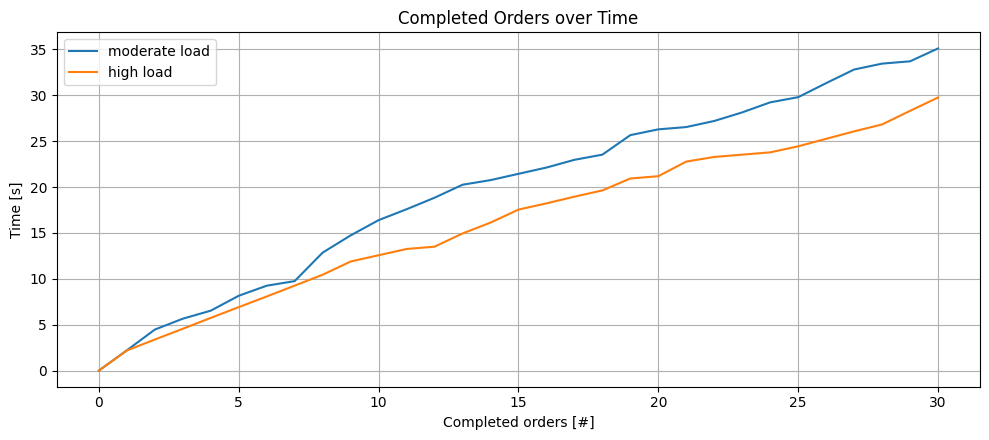

In [28]:
timestamp_dfs = [moderate_load_completed_df, high_load_completed_df]
labels = ['moderate load', 'high load']

# Plot all three with legend
plt.figure(figsize=(10, 4.5))
for timestamp_df,label in zip(timestamp_dfs,labels):
    plt.plot(timestamp_df['CompletedOrdersCount'], timestamp_df['Timestamp'] / 1e9, label=label)
plt.xlabel('Completed orders [#]')
plt.ylabel('Time [s]')
plt.title('Completed Orders over Time')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [29]:
print("moderate load makespan: {0:.3f} s".format(moderate_load_completed_df['Timestamp'].iloc[-1]/1e9))
print("high load makespan: {0:.3f} s".format(high_load_completed_df['Timestamp'].iloc[-1]/1e9))

moderate load makespan: 35.093 s
high load makespan: 29.750 s


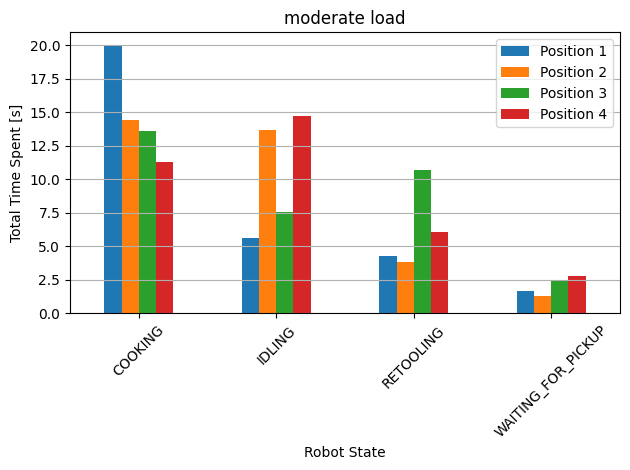

Total time recorded for Position 1: 31.566 seconds
Total utilized time for Position 1 (w/o IDLING and WAITING_FOR_PICKUP): 24.256 seconds (76.84%)
Total time recorded for Position 2: 33.189 seconds
Total utilized time for Position 2 (w/o IDLING and WAITING_FOR_PICKUP): 18.263 seconds (55.03%)
Total time recorded for Position 3: 34.281 seconds
Total utilized time for Position 3 (w/o IDLING and WAITING_FOR_PICKUP): 24.247 seconds (70.73%)
Total time recorded for Position 4: 34.843 seconds
Total utilized time for Position 4 (w/o IDLING and WAITING_FOR_PICKUP): 17.307 seconds (49.67%)


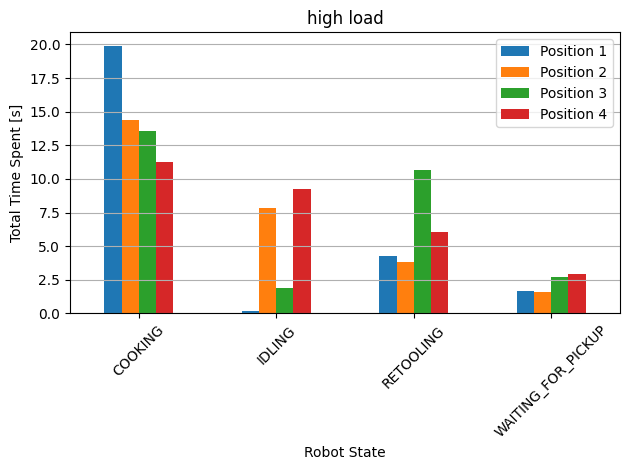

Total time recorded for Position 1: 26.062 seconds
Total utilized time for Position 1 (w/o IDLING and WAITING_FOR_PICKUP): 24.194 seconds (92.83%)
Total time recorded for Position 2: 27.685 seconds
Total utilized time for Position 2 (w/o IDLING and WAITING_FOR_PICKUP): 18.223 seconds (65.82%)
Total time recorded for Position 3: 28.777 seconds
Total utilized time for Position 3 (w/o IDLING and WAITING_FOR_PICKUP): 24.205 seconds (84.11%)
Total time recorded for Position 4: 29.499 seconds
Total utilized time for Position 4 (w/o IDLING and WAITING_FOR_PICKUP): 17.272 seconds (58.55%)


In [30]:
from enum import IntEnum

# State enums
class RobotState(IntEnum):
    IDLING = 0
    COOKING = 1
    RETOOLING = 2
    WAITING_FOR_PICKUP = 3
    REARRANGING = 4
    RECONFIGURING = 5

# helper mapping from numeric state to name
ROBOT_STATE_NAME = {state.value: state.name for state in RobotState}

# Method to analyze time spent in each state per robot position
def analyze_time_spent_per_state(robot_stats_df):
    robot_times_spent_df = pd.DataFrame({
        'STATE_NAME': pd.Series(dtype='object'),
        'DURATION_NS': pd.Series(dtype='int64')
    })

    state_key = robot_stats_df['State'].iloc[0]
    start_time = robot_stats_df['Timestamp'].iloc[0]

    for _, row in robot_stats_df.iterrows():
        if row['State'] != state_key:
            end_time = row['Timestamp']
            time_in_state = end_time - start_time
            state_name = ROBOT_STATE_NAME[state_key]

            # append a row
            robot_times_spent_df = pd.concat(
                [
                    robot_times_spent_df,
                    pd.DataFrame(
                        {'STATE_NAME': [state_name], 'DURATION_NS': [time_in_state]}
                    )
                ],
                ignore_index=True,
            )

            state_key = row['State']
            start_time = row['Timestamp']

    # handle last segment until the last timestamp
    end_time = robot_stats_df['Timestamp'].iloc[-1]
    time_in_state = end_time - start_time
    state_name = ROBOT_STATE_NAME[state_key]
    robot_times_spent_df = pd.concat(
        [
            robot_times_spent_df,
            pd.DataFrame({'STATE_NAME': [state_name], 'DURATION_NS': [time_in_state]})
        ],
        ignore_index=True,
    )
    return robot_times_spent_df

def plot_statistics(statistics_df, title):
    # Extract list of robot positions present in the dataframe
    positions = sorted(statistics_df['Position'].unique().tolist())
    position_dfs = [(statistics_df[statistics_df['Position'] == position].copy()) for position in positions]
    time_spent_dfs = [analyze_time_spent_per_state(pos_df) for pos_df in position_dfs]
    aggregated_time_spent_dfs = []
    for time_spent_df in time_spent_dfs:
        aggregated_df = (
            time_spent_df
            .groupby('STATE_NAME', as_index=False)['DURATION_NS']
            .sum()
        )
        aggregated_time_spent_dfs.append(aggregated_df)

    combined = pd.DataFrame()
    for i, df in enumerate(aggregated_time_spent_dfs):
        # Set STATE_NAME as index
        df = df.set_index("STATE_NAME")
        # Rename the DURATION_NS column
        df = df.rename(columns={"DURATION_NS": f"Position {i+1}"})
        # Add the column to the combined DF
        combined = pd.concat([combined, df], axis=1)
    combined = combined.fillna(0)
    combined = combined / 1e9  # convert to seconds

    ax = combined.plot.bar(rot=45, title=title)
    ax.set_xlabel('Robot State')
    ax.set_ylabel('Total Time Spent [s]')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Sum up total time
    for i, aggregated_df in enumerate(aggregated_time_spent_dfs):
        total_time_s = aggregated_df['DURATION_NS'].sum()
        print(f"Total time recorded for Position {i+1}: {total_time_s / 1e9:.3f} seconds")
        total_utilized_time = aggregated_df[~aggregated_df['STATE_NAME'].isin(['IDLING', 'WAITING_FOR_PICKUP'])]['DURATION_NS'].sum()
        print(f"Total utilized time for Position {i+1} (w/o IDLING and WAITING_FOR_PICKUP): {total_utilized_time / 1e9:.3f} seconds ({total_utilized_time / total_time_s * 100:.2f}%)")

# Evaluate statistics results
statistics_dfs = [(moderate_load_df,'moderate load'), (high_load_df, 'high load')]
for statistic_df, label in statistics_dfs:
    plot_statistics(statistic_df,label)

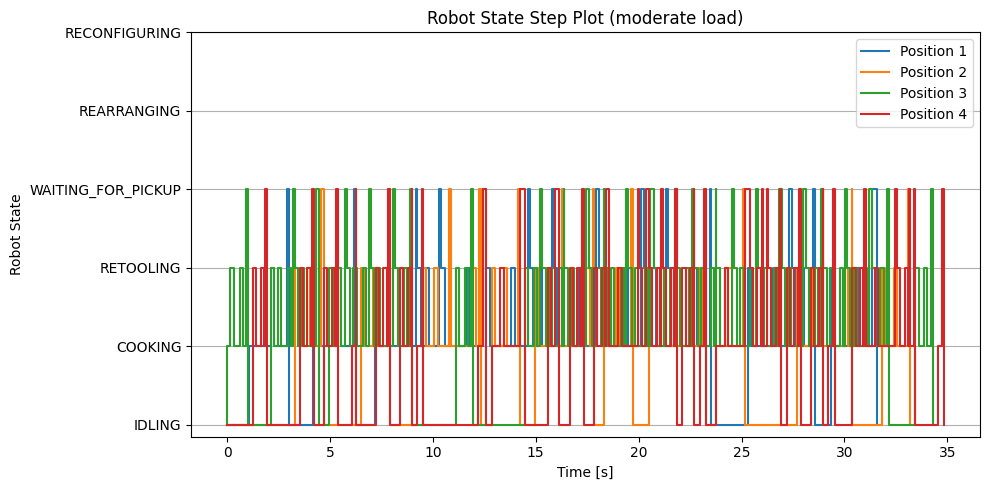

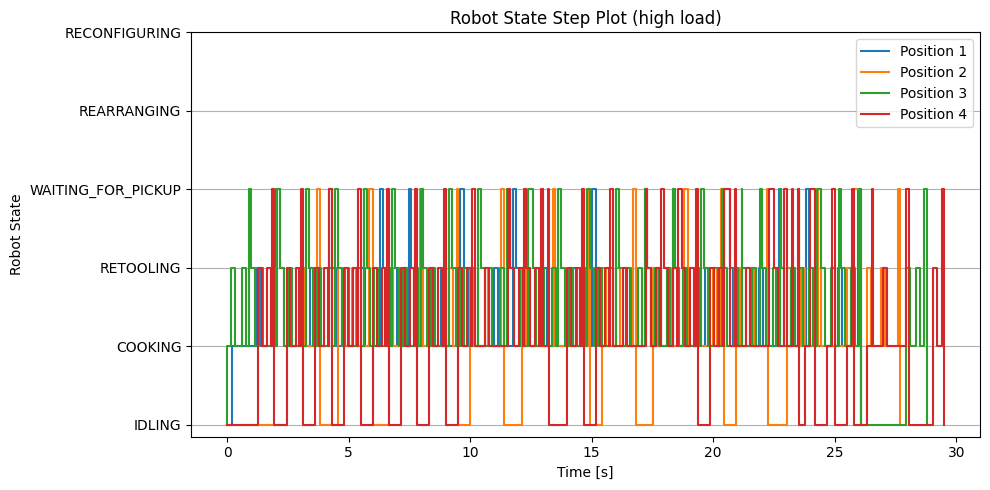

In [31]:
def plot_step_plot(statistics_df, title_addition):
    plt.figure(figsize=(10, 5))
    positions = sorted(statistics_df['Position'].unique().tolist())
    for pos in positions:
        pos_df = statistics_df[statistics_df['Position'] == pos]
        plt.step(pos_df['Timestamp'] / 1e9, pos_df['State'], where='post', label=f'Position {pos}')

    # Map y-ticks to state names
    state_vals = sorted(ROBOT_STATE_NAME.keys())
    plt.yticks(state_vals, [ROBOT_STATE_NAME[v] for v in state_vals])

    plt.xlabel('Time [s]')
    plt.ylabel('Robot State')
    plt.title(f'Robot State Step Plot ({title_addition})')
    plt.grid(True, axis='y')
    plt.legend()
    plt.tight_layout()
    plt.show()

stat_dfs = [moderate_load_df, high_load_df]
titles = ['moderate load', 'high load']
for stat_df, title in zip(stat_dfs, titles):
    plot_step_plot(stat_df, title)

